## ✅ Atividade 1 — Semi-supervisionado (Self-Training) com SpamBase (OpenML id=44)

### Objetivo
Melhorar um classificador de spam usando poucos rótulos + pseudo-rotulagem.

### Dataset
SpamBase (57 features numéricas; rótulo binário spam vs. não-spam).

### Passo a passo

1. Carregar e criar cenário de poucos rótulos (10%)

In [1]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
import pandas as pd

# 1. Carregar e criar cenário de poucos rótulos (10%)
print("Carregando dataset SpamBase (OpenML id=44)...")
data = fetch_openml(data_id=44, as_frame=True)
X = data.data
y = data.target.astype(int)

print(f"Dataset carregado: {X.shape[0]} amostras, {X.shape[1]} features.")
print(f"Classes: {y.value_counts().to_dict()}")

X_train_pool, X_test, y_train_pool, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"\nTamanho do conjunto de treino/pool: {X_train_pool.shape[0]}")
print(f"Tamanho do conjunto de teste (final): {X_test.shape[0]}")

X_lab, X_unlab, y_lab, y_unlab = train_test_split(
    X_train_pool, y_train_pool, test_size=0.9, stratify=y_train_pool, random_state=42
)

print(f"\nTamanho do conjunto de dados rotulados (inicial): {X_lab.shape[0]} ({len(X_lab)/X_train_pool.shape[0]*100:.1f}% do pool)")
print(f"Tamanho do conjunto de dados não rotulados: {X_unlab.shape[0]} ({len(X_unlab)/X_train_pool.shape[0]*100:.1f}% do pool)")

print("Cenário de poucos rótulos criado com sucesso.")



Carregando dataset SpamBase (OpenML id=44)...
Dataset carregado: 4601 amostras, 57 features.
Classes: {0: 2788, 1: 1813}

Tamanho do conjunto de treino/pool: 3680
Tamanho do conjunto de teste (final): 921

Tamanho do conjunto de dados rotulados (inicial): 368 (10.0% do pool)
Tamanho do conjunto de dados não rotulados: 3312 (90.0% do pool)
Cenário de poucos rótulos criado com sucesso.


2. Baseline supervisionado (somente 10%)

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix

# 2. Baseline supervisionado (somente 10%)
print("--- Treinando modelo Baseline (somente com dados rotulados iniciais) ---")

baseline_model = LogisticRegression(random_state=42, solver='liblinear', max_iter=1000)
# Treina o modelo baseline apenas com os dados rotulados (10%)
baseline_model.fit(X_lab, y_lab)

# Faz previsões no conjunto de teste (o conjunto de teste completo, não apenas o 10%)
y_pred_baseline = baseline_model.predict(X_test)

# Avalia o modelo baseline
print("\n--- Performance do Modelo Baseline ---")
print(f"Acurácia: {accuracy_score(y_test, y_pred_baseline):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_baseline):.4f}")
print(f"Precisão: {precision_score(y_test, y_pred_baseline):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_baseline):.4f}")

# Armazena as métricas para comparação futura
baseline_metrics = {
    'accuracy': accuracy_score(y_test, y_pred_baseline),
    'f1': f1_score(y_test, y_pred_baseline),
    'precision': precision_score(y_test, y_pred_baseline),
    'recall': recall_score(y_test, y_pred_baseline)
}


--- Treinando modelo Baseline (somente com dados rotulados iniciais) ---

--- Performance do Modelo Baseline ---
Acurácia: 0.9012
F1 Score: 0.8752
Precisão: 0.8716
Recall: 0.8788


3. Self-Training (pseudo-rotulagem)

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import numpy as np
import pandas as pd

X_train_self_training = X_lab.copy()
y_train_self_training = y_lab.copy()
X_unlabeled_st = X_unlab.copy()
y_unlabeled_st_true_labels = y_unlab.copy()

self_training_model = LogisticRegression(random_state=42, solver='liblinear', max_iter=1000)

max_iterations = 10
confidence_threshold = 0.9

print("--- Iniciando Processo de Self-Training ---")

for i in range(max_iterations):
    print(f"\nIteração {i+1}/{max_iterations}")

    if X_unlabeled_st.empty:
        print("Não há mais dados não rotulados para pseudo-rotular. Parando self-training.")
        break

    # 1. Treina o modelo nos dados rotulados atuais
    self_training_model.fit(X_train_self_training, y_train_self_training)

    # 2. Preve as probabilidades nos dados não rotulados
    # Usa predict_proba para obter pontuações de confiança para cada classe
    y_proba_unlabeled = self_training_model.predict_proba(X_unlabeled_st)

    # Obtém a probabilidade máxima para cada amostra e a classe prevista
    max_probas = np.max(y_proba_unlabeled, axis=1)
    predicted_classes = np.argmax(y_proba_unlabeled, axis=1)

    # 3. Identifica amostras com alta confiança
    high_confidence_indices = np.where(max_probas >= confidence_threshold)[0]

    if len(high_confidence_indices) == 0:
        print("Nenhuma amostra com alta confiança encontrada. Parando self-training.")
        break

    # 4. Pseudo-rotula essas amostras
    X_pseudo_labeled = X_unlabeled_st.iloc[high_confidence_indices]
    y_pseudo_labeled = predicted_classes[high_confidence_indices]

    print(f"Encontradas {len(high_confidence_indices)} amostras com alta confiança para pseudo-rotulagem.")

    # 5. Adiciona amostras pseudo-rotuladas ao conjunto rotulado
    X_train_self_training = pd.concat([X_train_self_training, X_pseudo_labeled])
    y_train_self_training = pd.concat([y_train_self_training, pd.Series(y_pseudo_labeled, index=X_pseudo_labeled.index)])

    # 6. Remove essas amostras do conjunto não rotulado
    X_unlabeled_st = X_unlabeled_st.drop(index=X_pseudo_labeled.index)
    y_unlabeled_st_true_labels = y_unlabeled_st_true_labels.drop(index=X_pseudo_labeled.index)

    print(f"Tamanho dos dados rotulados: {len(X_train_self_training)}")
    print(f"Dados não rotulados restantes: {len(X_unlabeled_st)}")

print("--- Self-Training Concluído ---")

# Avalia o modelo final de self-training no conjunto de teste original
y_pred_self_training = self_training_model.predict(X_test)

print("\n--- Performance do Modelo Self-Training (com pseudo-rotulagem) ---")
print(f"Acurácia: {accuracy_score(y_test, y_pred_self_training):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_self_training):.4f}")
print(f"Precisão: {precision_score(y_test, y_pred_self_training):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_self_training):.4f}")

# Armazena as métricas para comparação futura
self_training_metrics = {
    'accuracy': accuracy_score(y_test, y_pred_self_training),
    'f1': f1_score(y_test, y_pred_self_training),
    'precision': precision_score(y_test, y_pred_self_training),
    'recall': recall_score(y_test, y_pred_self_training)
}

--- Iniciando Processo de Self-Training ---

Iteração 1/10
Encontradas 1965 amostras com alta confiança para pseudo-rotulagem.
Tamanho dos dados rotulados: 2333
Dados não rotulados restantes: 1347

Iteração 2/10
Encontradas 409 amostras com alta confiança para pseudo-rotulagem.
Tamanho dos dados rotulados: 2742
Dados não rotulados restantes: 938

Iteração 3/10
Encontradas 229 amostras com alta confiança para pseudo-rotulagem.
Tamanho dos dados rotulados: 2971
Dados não rotulados restantes: 709

Iteração 4/10
Encontradas 133 amostras com alta confiança para pseudo-rotulagem.
Tamanho dos dados rotulados: 3104
Dados não rotulados restantes: 576

Iteração 5/10
Encontradas 39 amostras com alta confiança para pseudo-rotulagem.
Tamanho dos dados rotulados: 3143
Dados não rotulados restantes: 537

Iteração 6/10
Encontradas 15 amostras com alta confiança para pseudo-rotulagem.
Tamanho dos dados rotulados: 3158
Dados não rotulados restantes: 522

Iteração 7/10
Encontradas 7 amostras com alta con

4. Métricas e análise

- Compare baseline vs. self-training em F1, precision, recall.

- Gere matriz de confusão e comente erros típicos.

--- Comparação de Métricas: Baseline vs. Self-Training ---

Métrica    | Baseline   | Self-Training   | Melhora   
------------------------------------------------------------------
Accuracy   | 0.9012     | 0.8969         | -0.0043
F1         | 0.8752     | 0.8707         | -0.0044
Precision  | 0.8716     | 0.8602         | -0.0114
Recall     | 0.8788     | 0.8815         | +0.0028

--- Análise da Matriz de Confusão ---


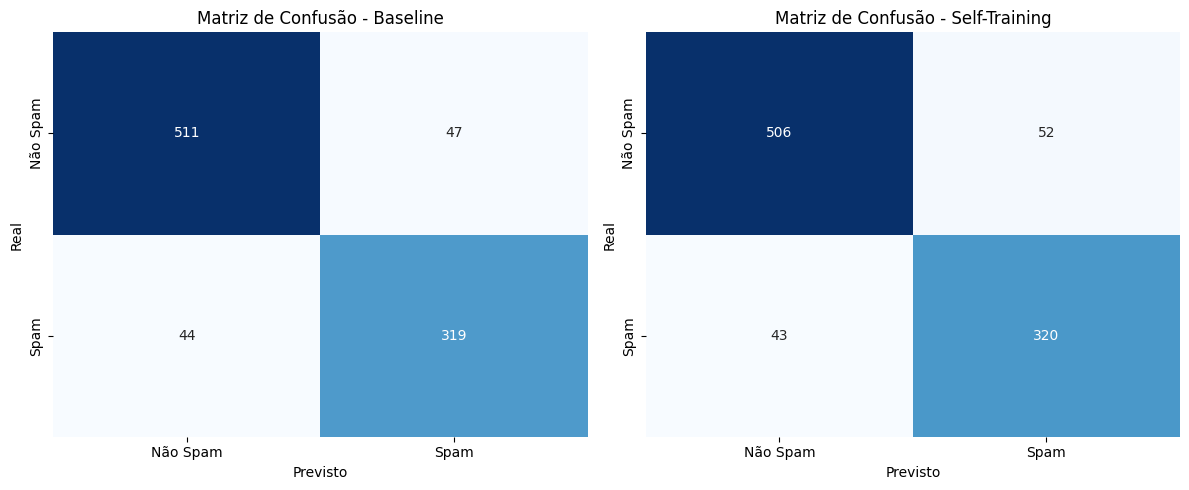


Comentários sobre Erros Típicos:
------------------------------------------------------------------
A matriz de confusão nos ajuda a entender os tipos de erros que cada modelo comete.
Para o *Modelo Baseline*:
  - Verdadeiros Positivos (TP): 319 (Spam corretamente identificado)
  - Verdadeiros Negativos (TN): 511 (Não Spam corretamente identificado)
  - Falsos Positivos (FP): 47 (Não Spam erroneamente classificado como Spam - Erro Tipo I)
  - Falsos Negativos (FN): 44 (Spam erroneamente classificado como Não Spam - Erro Tipo II)
  O erro Tipo I (Falso Positivo) significa que mensagens importantes podem ir para a caixa de spam. O erro Tipo II (Falso Negativo) significa que spam pode chegar à caixa de entrada.

Para o *Modelo Self-Training*:
  - Verdadeiros Positivos (TP): 320 (Spam corretamente identificado)
  - Verdadeiros Negativos (TN): 506 (Não Spam corretamente identificado)
  - Falsos Positivos (FP): 52 (Não Spam erroneamente classificado como Spam - Erro Tipo I)
  - Falsos Negat

In [4]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Comparação de Métricas: Baseline vs. Self-Training ---")
print(f"\n{'Métrica':<10} | {'Baseline':<10} | {'Self-Training':<15} | {'Melhora':<10}")
print("------------------------------------------------------------------")

for metric_name in ['accuracy', 'f1', 'precision', 'recall']:
    baseline_val = baseline_metrics[metric_name]
    self_training_val = self_training_metrics[metric_name]
    improvement = self_training_val - baseline_val
    print(f"{metric_name.capitalize():<10} | {baseline_val:.4f}     | {self_training_val:.4f}         | {improvement:+.4f}")

print("\n--- Análise da Matriz de Confusão ---")

# Matriz de Confusão para o Modelo Baseline
cm_baseline = confusion_matrix(y_test, y_pred_baseline)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Não Spam', 'Spam'], yticklabels=['Não Spam', 'Spam'])
plt.title('Matriz de Confusão - Baseline')
plt.xlabel('Previsto')
plt.ylabel('Real')

# Matriz de Confusão para o Modelo Self-Training
cm_self_training = confusion_matrix(y_test, y_pred_self_training)

plt.subplot(1, 2, 2)
sns.heatmap(cm_self_training, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Não Spam', 'Spam'], yticklabels=['Não Spam', 'Spam'])
plt.title('Matriz de Confusão - Self-Training')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

print("\nComentários sobre Erros Típicos:")
print("------------------------------------------------------------------")
print("A matriz de confusão nos ajuda a entender os tipos de erros que cada modelo comete.")

print("Para o *Modelo Baseline*:")
print(f"  - Verdadeiros Positivos (TP): {cm_baseline[1, 1]} (Spam corretamente identificado)")
print(f"  - Verdadeiros Negativos (TN): {cm_baseline[0, 0]} (Não Spam corretamente identificado)")
print(f"  - Falsos Positivos (FP): {cm_baseline[0, 1]} (Não Spam erroneamente classificado como Spam - Erro Tipo I)")
print(f"  - Falsos Negativos (FN): {cm_baseline[1, 0]} (Spam erroneamente classificado como Não Spam - Erro Tipo II)")
print("  O erro Tipo I (Falso Positivo) significa que mensagens importantes podem ir para a caixa de spam. O erro Tipo II (Falso Negativo) significa que spam pode chegar à caixa de entrada.")

print("\nPara o *Modelo Self-Training*:")
print(f"  - Verdadeiros Positivos (TP): {cm_self_training[1, 1]} (Spam corretamente identificado)")
print(f"  - Verdadeiros Negativos (TN): {cm_self_training[0, 0]} (Não Spam corretamente identificado)")
print(f"  - Falsos Positivos (FP): {cm_self_training[0, 1]} (Não Spam erroneamente classificado como Spam - Erro Tipo I)")
print(f"  - Falsos Negativos (FN): {cm_self_training[1, 0]} (Spam erroneamente classificado como Não Spam - Erro Tipo II)")
print("  Ao comparar com o baseline, podemos observar se o self-training conseguiu reduzir algum tipo de erro mais significativamente. Por exemplo, se a precisão melhorou, provavelmente houve uma redução nos Falsos Positivos. Se o recall melhorou, uma redução nos Falsos Negativos.")


## ✅ Atividade 2 — Auto-supervisionado (Autoencoder) com MNIST (Keras)

### Objetivo
Aprender representações sem rótulos via autoencoder e usá-las em tarefas simples.

### Dataset
MNIST (28×28, dígitos 0–9). Usaremos o pacote embutido do Keras.

### Passo a passo

1. Carregar, normalizar e “achatar”

In [5]:
import numpy as np
from tensorflow.keras.datasets import mnist

print("--- Carregando, normalizando e achatando o dataset MNIST ---")

# 1. Carregar o dataset MNIST
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print(f"Dataset MNIST carregado. Dimensões originais de treino: {x_train.shape}, teste: {x_test.shape}")

# 2. Normalizar os dados
# Converte para float32 e normaliza para o intervalo [0, 1]
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

# 3. 'Achatar' as imagens (reshape)
# Converte imagens de 28x28 para vetores de 784 (28*28)
x_train_flat = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test_flat = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))

print(f"Dados normalizados e achatados. Novas dimensões de treino: {x_train_flat.shape}, teste: {x_test_flat.shape}")

print("Processamento inicial do dataset MNIST concluído com sucesso.")


--- Carregando, normalizando e achatando o dataset MNIST ---
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Dataset MNIST carregado. Dimensões originais de treino: (60000, 28, 28), teste: (10000, 28, 28)
Dados normalizados e achatados. Novas dimensões de treino: (60000, 784), teste: (10000, 784)
Processamento inicial do dataset MNIST concluído com sucesso.
